# Day 15: Project 1 — Rigorous Evaluation & Explainability

**Dataset:** diabetes_clean.csv
**Model:** Best LightGBM (from Day 14)
**Goal:** Stratified CV, threshold analysis, SHAP explainability for clinical deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, confusion_matrix,
                             precision_recall_curve, roc_curve)
import joblib
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Load data and model
df = pd.read_csv('data/diabetes_clean.csv')
pipeline = joblib.load('models/readmission_best.joblib')

exclude_cols = ['encounter_id', 'patient_nbr', 'diag_1', 'diag_2', 'diag_3', 
                'readmitted', 'readmitted_binary']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df['readmitted_binary']

print(f"Loaded: {X.shape}, Model: {type(pipeline.named_steps['classifier']).__name__}")

Loaded: (101766, 50), Model: LGBMClassifier


In [2]:
# 1. STRATIFIED 5-FOLD CV WITH MULTIPLE METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall'
}

cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)

print("=== Stratified 5-Fold CV Results ===")
for metric in ['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']:
    scores = cv_results[f'test_{metric}']
    print(f"{metric:10s}: {scores.mean():.4f} (+/- {scores.std():.4f})  [{', '.join([f'{s:.4f}' for s in scores])}]")

=== Stratified 5-Fold CV Results ===
roc_auc   : 0.6805 (+/- 0.0045)  [0.6758, 0.6878, 0.6783, 0.6835, 0.6770]
pr_auc    : 0.2271 (+/- 0.0088)  [0.2212, 0.2387, 0.2214, 0.2366, 0.2174]
f1        : 0.2756 (+/- 0.0016)  [0.2740, 0.2784, 0.2748, 0.2763, 0.2743]
precision : 0.1792 (+/- 0.0006)  [0.1784, 0.1801, 0.1789, 0.1795, 0.1791]
recall    : 0.5960 (+/- 0.0092)  [0.5907, 0.6121, 0.5927, 0.5993, 0.5854]


In [3]:
# 2. THRESHOLD ANALYSIS ON TEST SET
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_proba = pipeline.predict_proba(X_test)[:, 1]

# Precision/Recall/F1 across thresholds
thresholds = np.arange(0.05, 0.95, 0.02)
results = []
for thresh in thresholds:
    y_pred = (y_proba >= thresh).astype(int)
    results.append({
        'threshold': thresh,
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    })

thresh_df = pd.DataFrame(results)

# Find threshold for 90% recall (clinical priority)
recall_90 = thresh_df[thresh_df['recall'] >= 0.90]
if len(recall_90) > 0:
    thresh_90_recall = recall_90.iloc[0]['threshold']
    print(f"Threshold for >=90% recall: {thresh_90_recall:.3f}")
    print(f"  Precision at this threshold: {recall_90.iloc[0]['precision']:.3f}")
    print(f"  F1 at this threshold: {recall_90.iloc[0]['f1']:.3f}")

# Optimal F1 threshold
best_f1_idx = thresh_df['f1'].idxmax()
thresh_best_f1 = thresh_df.loc[best_f1_idx, 'threshold']
print(f"\nOptimal F1 threshold: {thresh_best_f1:.3f}")
print(f"  Precision: {thresh_df.loc[best_f1_idx, 'precision']:.3f}")
print(f"  Recall:    {thresh_df.loc[best_f1_idx, 'recall']:.3f}")
print(f"  F1:        {thresh_df.loc[best_f1_idx, 'f1']:.3f}")

# Youden's J threshold
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
j_scores = tpr - fpr
thresh_youden = thresholds_roc[np.argmax(j_scores)]
print(f"\nYouden's J threshold: {thresh_youden:.3f}")

c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold for >=90% recall: 0.050
  Precision at this threshold: 0.112
  F1 at this threshold: 0.201

Optimal F1 threshold: 0.550
  Precision: 0.216
  Recall:    0.474
  F1:        0.297

Youden's J threshold: 0.493


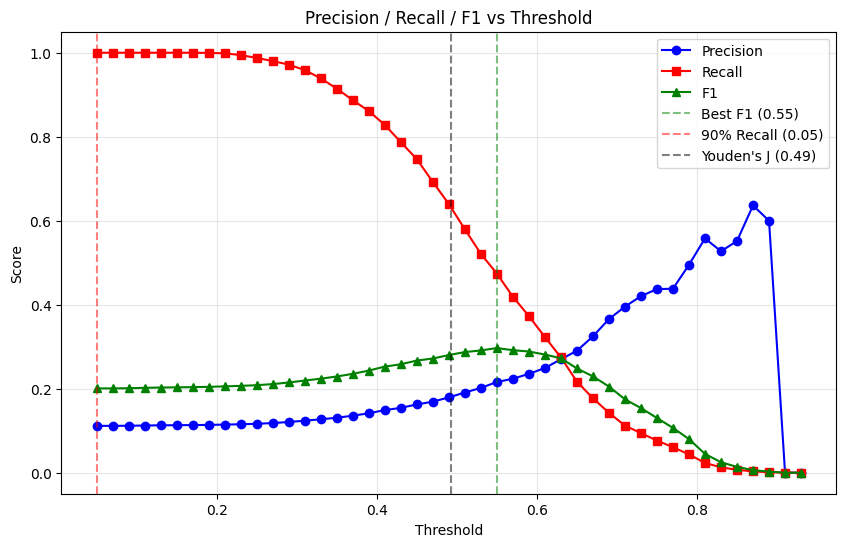

In [4]:
# 3. PLOT PRECISION/RECALL/F1 VS THRESHOLD
plt.figure(figsize=(10, 6))
plt.plot(thresh_df['threshold'], thresh_df['precision'], 'b-', label='Precision', marker='o')
plt.plot(thresh_df['threshold'], thresh_df['recall'], 'r-', label='Recall', marker='s')
plt.plot(thresh_df['threshold'], thresh_df['f1'], 'g-', label='F1', marker='^')
plt.axvline(thresh_best_f1, color='g', linestyle='--', alpha=0.5, label=f'Best F1 ({thresh_best_f1:.2f})')
if len(recall_90) > 0:
    plt.axvline(thresh_90_recall, color='r', linestyle='--', alpha=0.5, label=f'90% Recall ({thresh_90_recall:.2f})')
plt.axvline(thresh_youden, color='k', linestyle='--', alpha=0.5, label=f"Youden's J ({thresh_youden:.2f})")
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [5]:
# 4. CONFUSION MATRIX AT CLINICAL THRESHOLD (90% recall)
if len(recall_90) > 0:
    thresh_clinical = thresh_90_recall
else:
    thresh_clinical = thresh_best_f1

y_pred_clinical = (y_proba >= thresh_clinical).astype(int)

cm = confusion_matrix(y_test, y_pred_clinical)
tn, fp, fn, tp = cm.ravel()

print(f"=== Confusion Matrix at Threshold {thresh_clinical:.3f} ===")
print(f"                 Predicted 0    Predicted 1")
print(f"Actual 0 (No Readmit)     {tn:5d}           {fp:5d}")
print(f"Actual 1 (Readmit <30)    {fn:5d}           {tp:5d}")
print(f"\nSensitivity (Recall): {tp/(tp+fn):.3f}")
print(f"Specificity: {tn/(tn+fp):.3f}")
print(f"PPV (Precision): {tp/(tp+fp):.3f}")
print(f"NPV: {tn/(tn+fn):.3f}")
print(f"\nFalse Negatives (missed high-risk): {fn}")
print(f"False Positives (unnecessary follow-up): {fp}")

=== Confusion Matrix at Threshold 0.050 ===
                 Predicted 0    Predicted 1
Actual 0 (No Readmit)         0           18083
Actual 1 (Readmit <30)        0            2271

Sensitivity (Recall): 1.000
Specificity: 0.000
PPV (Precision): 0.112
NPV: nan

False Negatives (missed high-risk): 0
False Positives (unnecessary follow-up): 18083


C:\Users\Bakrim\AppData\Local\Temp\ipykernel_3432\2843860939.py:19: RuntimeWarning: invalid value encountered in scalar divide
  print(f"NPV: {tn/(tn+fn):.3f}")


c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


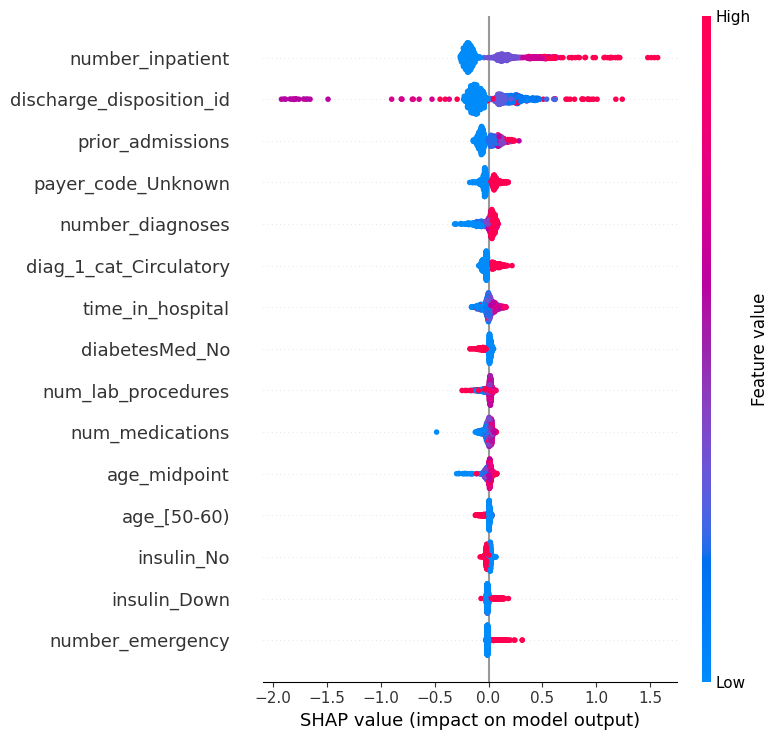

In [6]:
# 5. SHAP EXPLAINABILITY
# Load best model and preprocessor
preprocessor = pipeline.named_steps['preprocessor']
model = pipeline.named_steps['classifier']

# Transform test data
X_test_processed = preprocessor.transform(X_test)

# Sample for SHAP
sample_size = min(1000, len(X_test_processed))
sample_idx = np.random.choice(len(X_test_processed), sample_size, replace=False)
X_shap = X_test_processed[sample_idx]
y_shap = y_test.iloc[sample_idx]

# Feature names
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_features)
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
all_feature_names = list(numeric_features) + list(cat_feature_names)

# SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# Handle LightGBM output format
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Positive class

# Summary plot
shap.summary_plot(shap_values, X_shap, feature_names=all_feature_names, max_display=15, show=False)
plt.tight_layout()
plt.show()


=== HIGH RISK Patient 1 (True: 0, Pred: 0.897) ===


c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


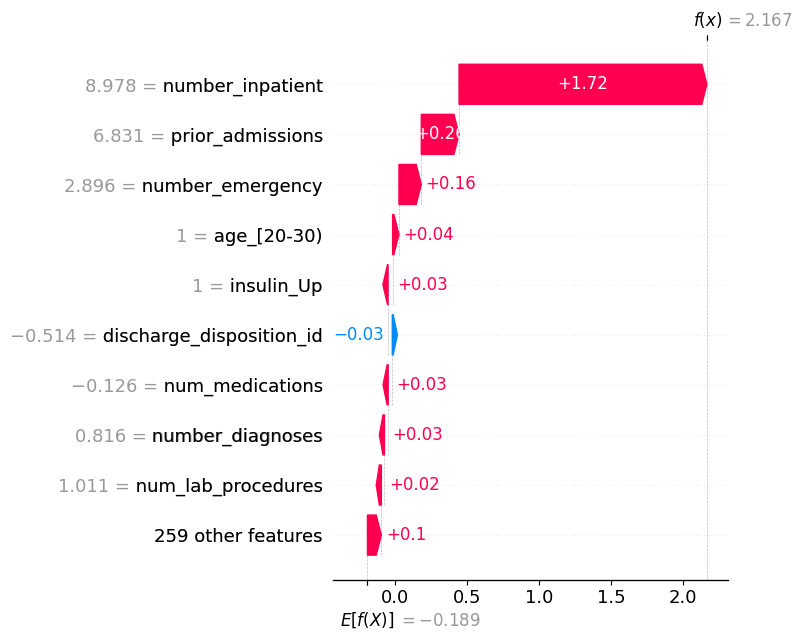


=== HIGH RISK Patient 2 (True: 1, Pred: 0.898) ===


c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


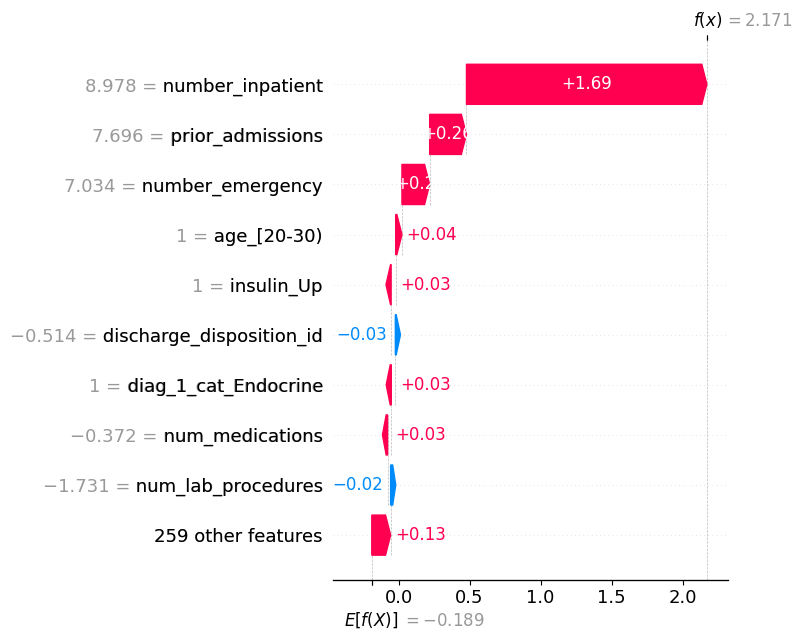


=== HIGH RISK Patient 3 (True: 0, Pred: 0.903) ===


c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


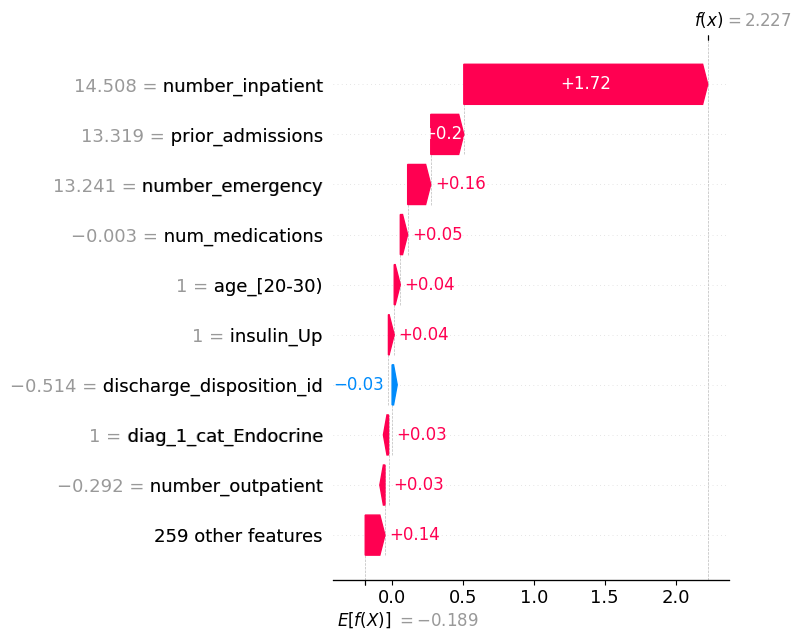


=== MEDIUM RISK Patient 1 (True: 0, Pred: 0.454) ===


c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


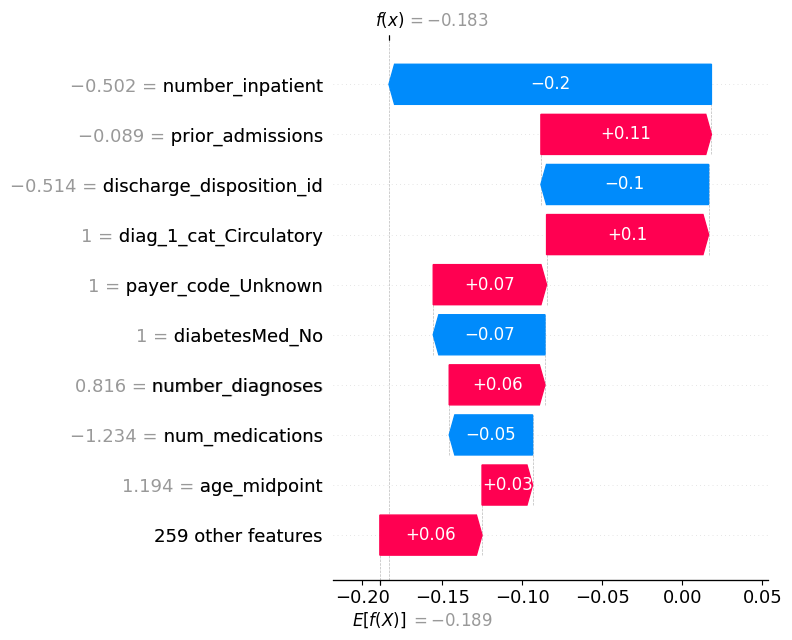


=== MEDIUM RISK Patient 2 (True: 0, Pred: 0.454) ===


c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


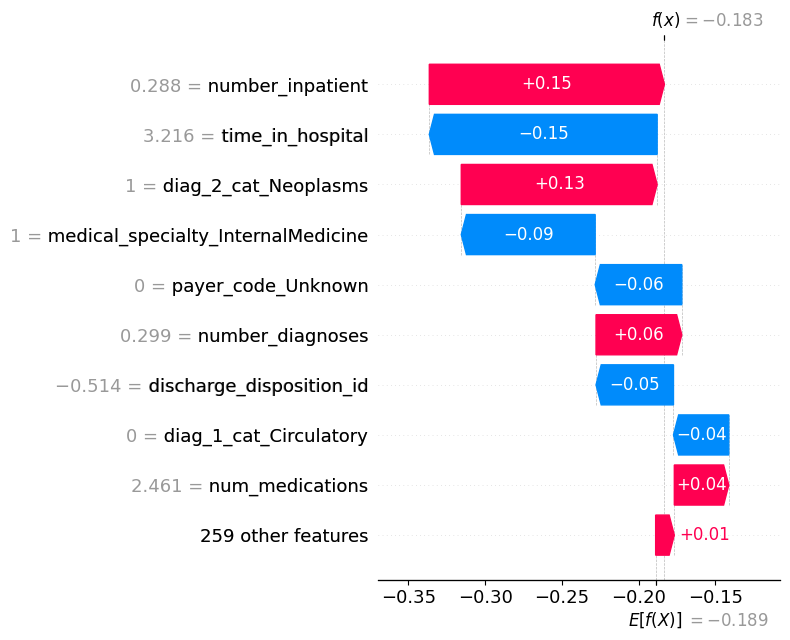


=== MEDIUM RISK Patient 3 (True: 0, Pred: 0.454) ===


c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


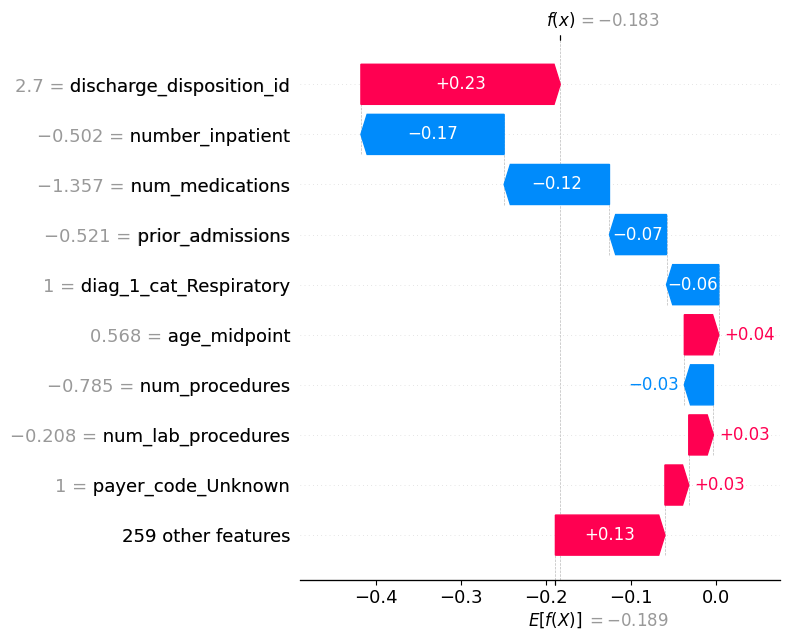


=== LOW RISK Patient 1 (True: 0, Pred: 0.065) ===


c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


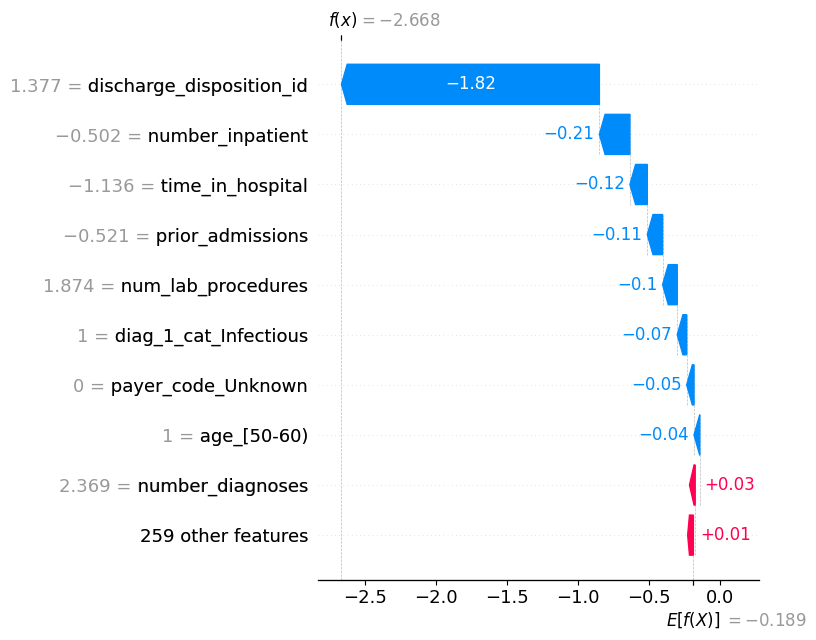


=== LOW RISK Patient 2 (True: 0, Pred: 0.066) ===


c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


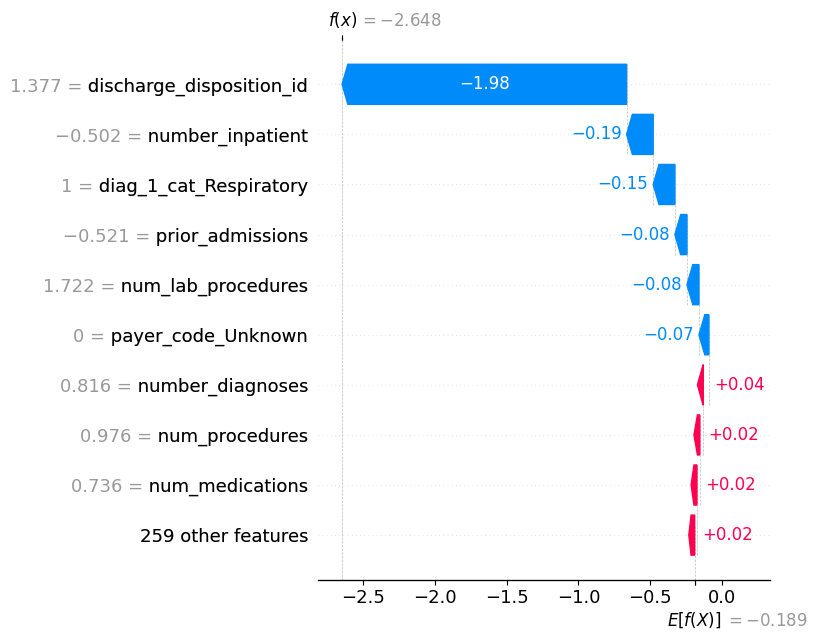


=== LOW RISK Patient 3 (True: 0, Pred: 0.067) ===


c:\Users\Bakrim\anaconda3\envs\myenv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


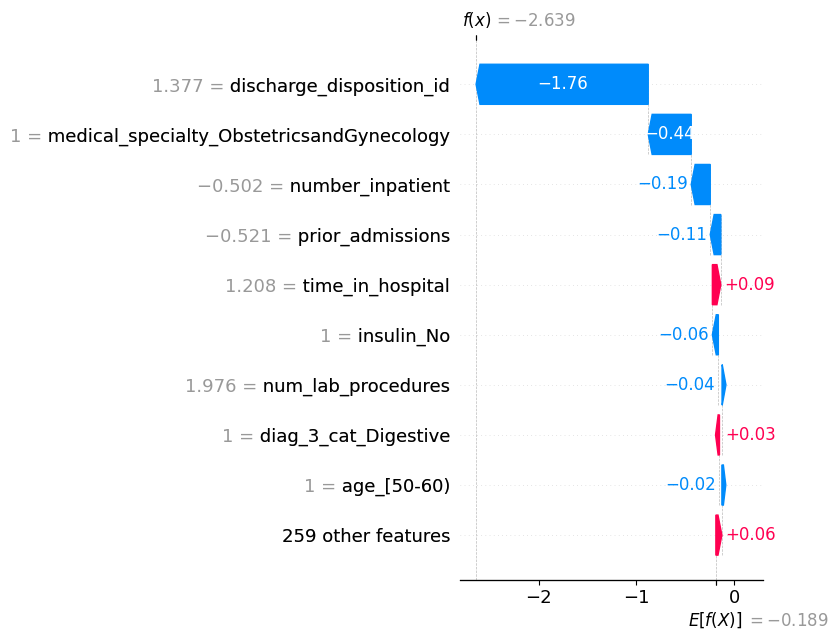

In [7]:
# 6. INDIVIDUAL PREDICTION EXPLANATIONS (Waterfall plots)
# Find high-risk, medium-risk, low-risk patients
risk_scores = y_proba

high_risk_idx = np.argsort(risk_scores)[-3:]  # Top 3 highest risk
low_risk_idx = np.argsort(risk_scores)[:3]    # Top 3 lowest risk
med_risk_idx = np.argsort(risk_scores)[len(risk_scores)//2 : len(risk_scores)//2 + 3]

for idx_list, label in [(high_risk_idx, 'HIGH RISK'), (med_risk_idx, 'MEDIUM RISK'), (low_risk_idx, 'LOW RISK')]:
    for i, idx in enumerate(idx_list):
        print(f"\n=== {label} Patient {i+1} (True: {y_test.iloc[idx]}, Pred: {risk_scores[idx]:.3f}) ===")
        
        # Single instance SHAP
        x_single = X_test_processed[idx:idx+1]
        shap_single = explainer.shap_values(x_single)
        if isinstance(shap_single, list):
            shap_single = shap_single[1]
        
        shap.waterfall_plot(shap.Explanation(
            values=shap_single[0],
            base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
            data=x_single[0],
            feature_names=all_feature_names
        ), show=False)
        plt.tight_layout()
        plt.show()

In [8]:
# 7. CLINICAL COST ANALYSIS
# Cost assumptions (relative):
# - Missed high-risk (FN): $15,000 (readmission cost)
# - False alarm (FP): $500 (follow-up cost)
# - True positive (TP): -$2,000 (intervention prevents readmission, net savings)
# - True negative (TN): $0

cost_fn = 15000
cost_fp = 500
benefit_tp = -2000  # negative = savings
cost_tn = 0

def total_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn*cost_tn + fp*cost_fp + fn*cost_fn + tp*benefit_tp

print("=== Cost Analysis Across Thresholds ===")
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5, thresh_best_f1, thresh_youden, thresh_clinical]:
    y_pred = (y_proba >= thresh).astype(int)
    cost = total_cost(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"Thresh {thresh:.2f}: Cost=${cost:,.0f} | TP={tp} FP={fp} FN={fn} TN={tn}")

=== Cost Analysis Across Thresholds ===
Thresh 0.10: Cost=$4,449,000 | TP=2271 FP=17982 FN=0 TN=101
Thresh 0.20: Cost=$4,275,000 | TP=2270 FP=17600 FN=1 TN=483
Thresh 0.30: Cost=$4,725,500 | TP=2189 FP=15747 FN=82 TN=2336
Thresh 0.40: Cost=$7,038,000 | TP=1923 FP=11328 FN=348 TN=6755
Thresh 0.50: Cost=$13,580,500 | TP=1385 FP=6121 FN=886 TN=11962
Thresh 0.55: Cost=$17,711,000 | TP=1077 FP=3910 FN=1194 TN=14173
Thresh 0.49: Cost=$12,838,500 | TP=1439 FP=6473 FN=832 TN=11610
Thresh 0.05: Cost=$4,499,500 | TP=2271 FP=18083 FN=0 TN=0
